# 05.03 — Final Model: Evaluation, SHAP & Predictions
**Goal:**
1. Load the best model from experiments
2. Full evaluation with all plots
3. SHAP explanations — why is each customer high risk?
4. Score ALL 2025 Won customers → produce final prediction CSV
5. The prediction CSV is what the customer success team uses

**The final output:** `reports/churn_predictions_2025.csv`
- Co_Ref
- churn_probability (0-1)
- risk_tier (Critical / High / Medium / Low)
- top 3 reasons per customer

**Churn definition:** Post-renewal 4-week window — `Closed_Date` within 28 days after `Prospect_Renewal_Date`, `Prospect_Outcome = Churned` → label 1.


In [2]:
print("hello")

hello


In [3]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, str(__import__('pathlib').Path.cwd().parents[1]))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import stats

from src.data.loader import load_all
from src.data.cleaner import clean_all

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 60)

PROJECT_ROOT = Path.cwd().parents[1]
FEATURES = PROJECT_ROOT / 'data' / 'features'
MODELS   = PROJECT_ROOT / 'models_saved'
REPORTS  = PROJECT_ROOT / 'reports' / 'figures'
REPORTS.mkdir(parents=True, exist_ok=True)

raw  = load_all()
data = clean_all(raw)
bills = data['billings']
cc    = data['cc_calls']
emails= data['emails']
rc    = data['renewal_calls']

print("All files loaded and cleaned.")
print(f"  billings:      {bills.shape}")
print(f"  cc_calls:      {cc.shape}")
print(f"  emails:        {emails.shape}")
print(f"  renewal_calls: {rc.shape}")

import json, shap
from xgboost import XGBClassifier
from src.features.builder import build_cohort_features, get_feature_columns
from src.models.train import find_optimal_threshold, assign_risk_tier, DEFAULT_PARAMS
from src.models.evaluate import evaluate_model, plot_feature_importance, threshold_analysis, plot_calibration


All files loaded and cleaned.
  billings:      (122082, 59)
  cc_calls:      (32882, 34)
  emails:        (123389, 28)
  renewal_calls: (186534, 41)


## Load Model and Feature Tables

In [4]:

train_df = pd.read_parquet(FEATURES / 'train_2024.parquet')
test_df  = pd.read_parquet(FEATURES / 'test_2025.parquet')

with open(FEATURES / 'final_feature_cols.json') as f:
    feature_cols = json.load(f)
with open(MODELS / 'best_params.json') as f:
    best_params = json.load(f)

best_params['scale_pos_weight'] = best_params.get('scale_pos_weight', 9.5)
best_params['random_state'] = 42
best_params['n_jobs'] = -1

test_decided = test_df[test_df['churn_label'].notna()].copy()
test_decided['churn_label'] = test_decided['churn_label'].astype(int)

X_train = train_df[feature_cols]
y_train = train_df['churn_label'].astype(int)
X_test  = test_decided[feature_cols]
y_test  = test_decided['churn_label']

print(f"Train: {X_train.shape}")
print(f"Test (decided): {X_test.shape}")
print(f"Features: {len(feature_cols)}")


Train: (6686, 45)
Test (decided): (6219, 45)
Features: 45


## Retrain on Full Training Set with Best Params

In [5]:

final_model = XGBClassifier(**best_params)
final_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=50)
final_model.save_model(str(MODELS / 'churn_model_final.json'))
print("Final model saved.")


[0]	validation_0-aucpr:0.46109
[50]	validation_0-aucpr:0.57540
[100]	validation_0-aucpr:0.58069
[150]	validation_0-aucpr:0.58736
[200]	validation_0-aucpr:0.59234
[250]	validation_0-aucpr:0.59706
[300]	validation_0-aucpr:0.59786
[350]	validation_0-aucpr:0.59729
[400]	validation_0-aucpr:0.59502
[450]	validation_0-aucpr:0.59447
[500]	validation_0-aucpr:0.59339
[550]	validation_0-aucpr:0.59427
[599]	validation_0-aucpr:0.59060
Final model saved.


## Full Evaluation on Test Set

Model Evaluation — final
  Threshold used:    0.474
  PR-AUC:            0.5910
  ROC-AUC:           0.8731
  Precision:         0.5137
  Recall:            0.6586
  F1:                0.5772

  Total test customers:  6,219
  Actual churners:       1,113
  Customers flagged:     1,427
  Churners caught:       733 (65.9%)
  Churners missed:       380

              precision    recall  f1-score   support

    Retained       0.92      0.86      0.89      5106
     Churned       0.51      0.66      0.58      1113

    accuracy                           0.83      6219
   macro avg       0.72      0.76      0.73      6219
weighted avg       0.85      0.83      0.84      6219



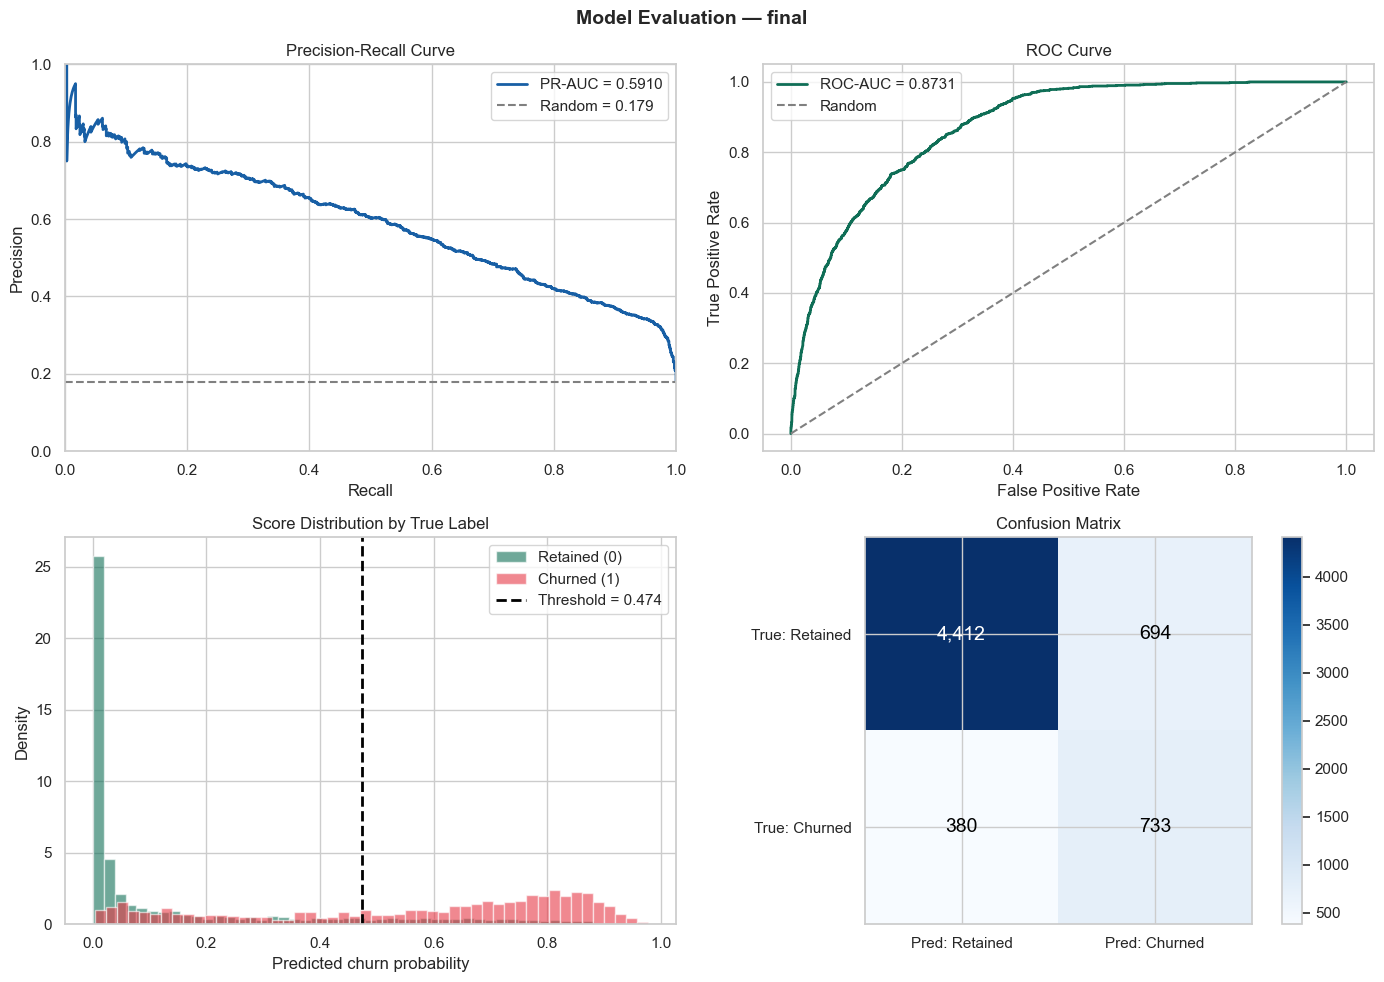

Plot saved → C:\ds-project\post_renewal_churn_prediction\reports\figures\final_evaluation.png

Optimal threshold: 0.474

Full threshold analysis:
 threshold  precision  recall     f1  flagged  caught
    0.0500     0.3450  0.9430 0.5050     3045    1050
    0.1000     0.3750  0.8920 0.5280     2649     993
    0.1500     0.3980  0.8500 0.5420     2379     946
    0.2000     0.4150  0.8170 0.5500     2193     909
    0.2500     0.4300  0.7850 0.5560     2033     874
    0.3000     0.4440  0.7580 0.5600     1900     844
    0.3500     0.4680  0.7390 0.5730     1756     822
    0.4000     0.4810  0.7060 0.5720     1633     786
    0.4500     0.4990  0.6700 0.5720     1496     746
    0.5000     0.5220  0.6340 0.5730     1352     706


In [6]:

final_metrics = evaluate_model(final_model, X_test, y_test,
                                model_name='final', save_plots=True)

proba_test = final_model.predict_proba(X_test)[:,1]
optimal_threshold = find_optimal_threshold(y_test.values, proba_test,
                                            min_precision=0.25, min_recall=0.50)
print(f"\nOptimal threshold: {optimal_threshold:.3f}")
print("\nFull threshold analysis:")
_ = threshold_analysis(y_test.values, proba_test)


## Calibration

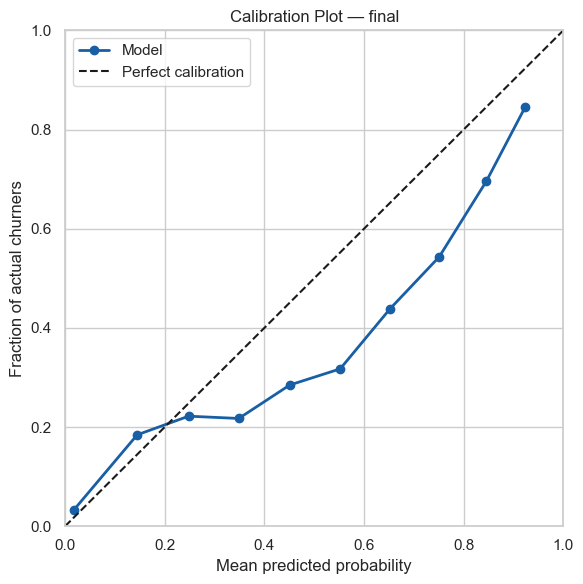

Saved → C:\ds-project\post_renewal_churn_prediction\reports\figures\final_calibration.png


In [7]:

plot_calibration(y_test.values, proba_test, model_name='final')


## Feature Importance — Final Model

Saved → C:\ds-project\post_renewal_churn_prediction\reports\figures\final_feature_importance.png


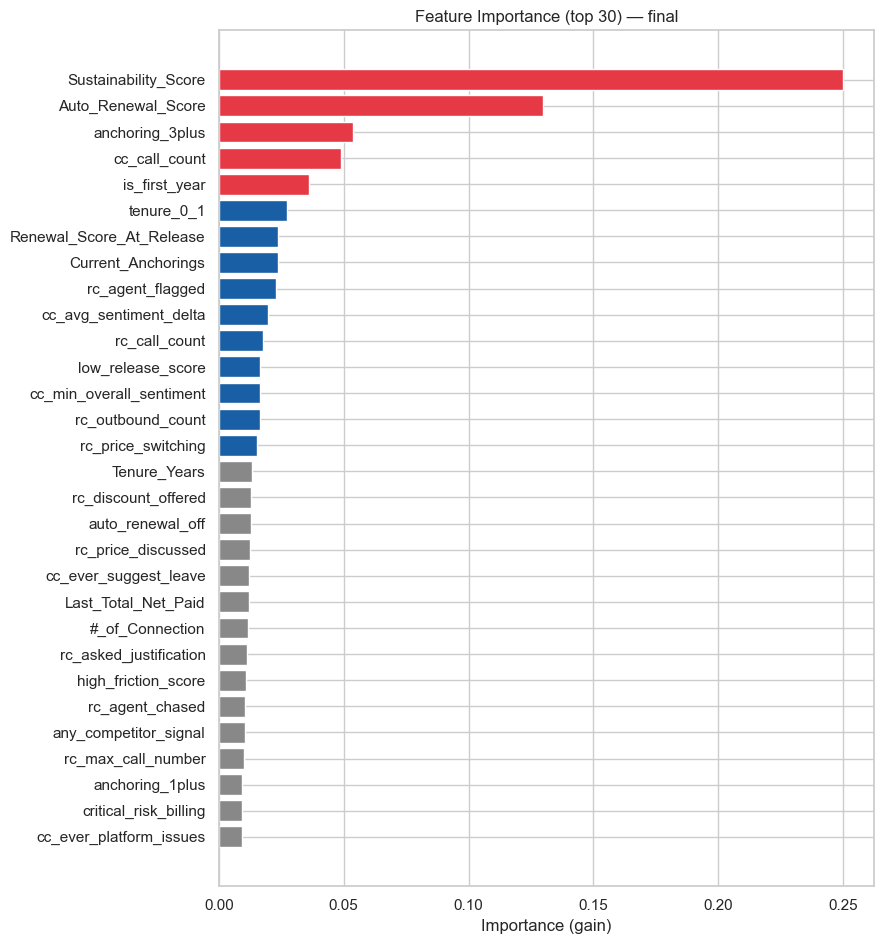

In [8]:

fi_df = plot_feature_importance(final_model, feature_cols, top_n=30, model_name='final')


## SHAP Explanations
**Why SHAP?**
Feature importance tells you what the model uses globally.
SHAP tells you WHY a specific customer was scored high — personalised explanations.
This is what the customer success team needs for their outreach conversations.


Computing SHAP values (this takes ~1-2 minutes)...
SHAP values shape: (6686, 45)


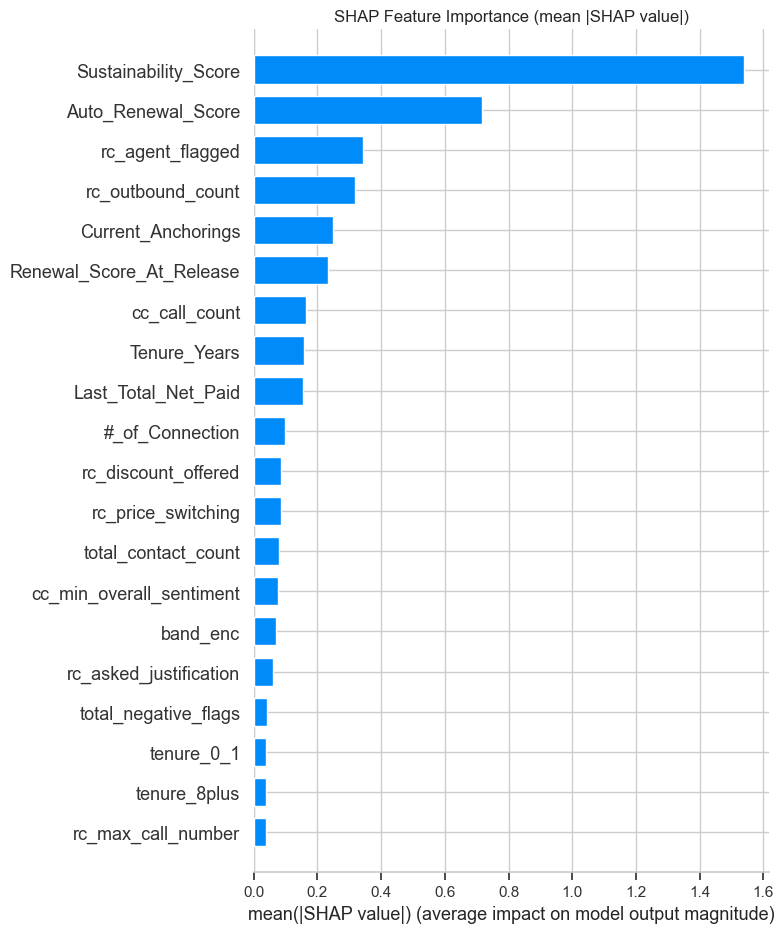

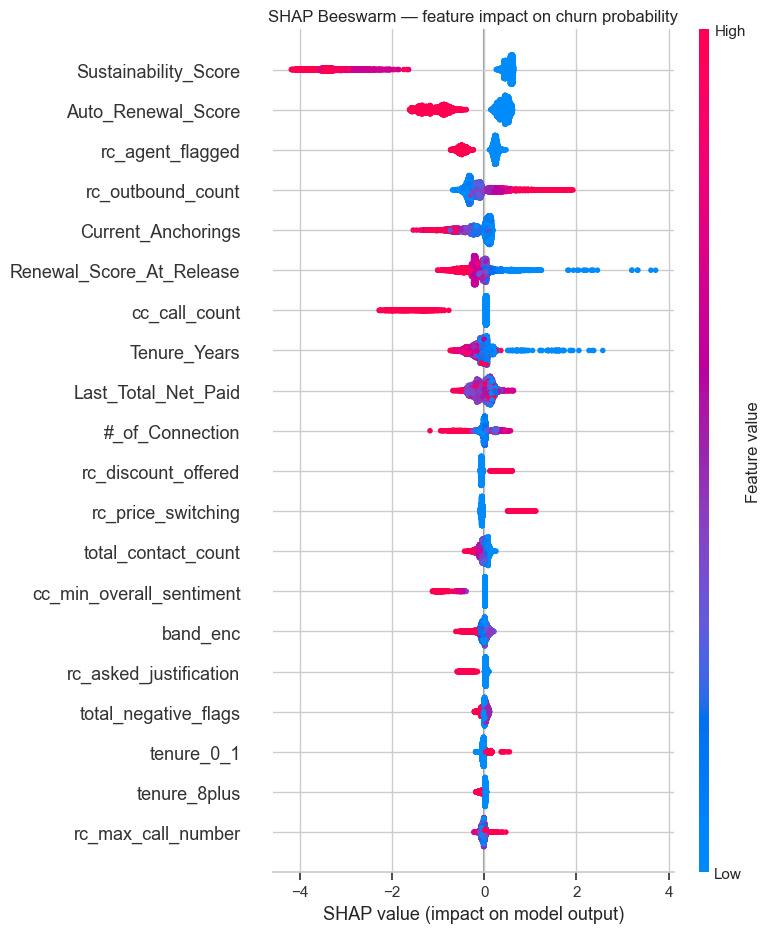

In [9]:

print("Computing SHAP values (this takes ~1-2 minutes)...")
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_train)

print(f"SHAP values shape: {shap_values.shape}")

# ── Global SHAP summary plot ──────────────────────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_train, feature_names=feature_cols,
                  plot_type='bar', show=False, max_display=20)
plt.title('SHAP Feature Importance (mean |SHAP value|)')
plt.tight_layout()
plt.savefig(REPORTS / 'shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Beeswarm plot (shows direction too) ──────────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_train, feature_names=feature_cols,
                  plot_type='dot', show=False, max_display=20)
plt.title('SHAP Beeswarm — feature impact on churn probability')
plt.tight_layout()
plt.savefig(REPORTS / 'shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()


## SHAP Individual Customer Explanation Examples


Rank 1 highest risk — Co_Ref: MI9888  Probability: 0.980
Actual label: 1


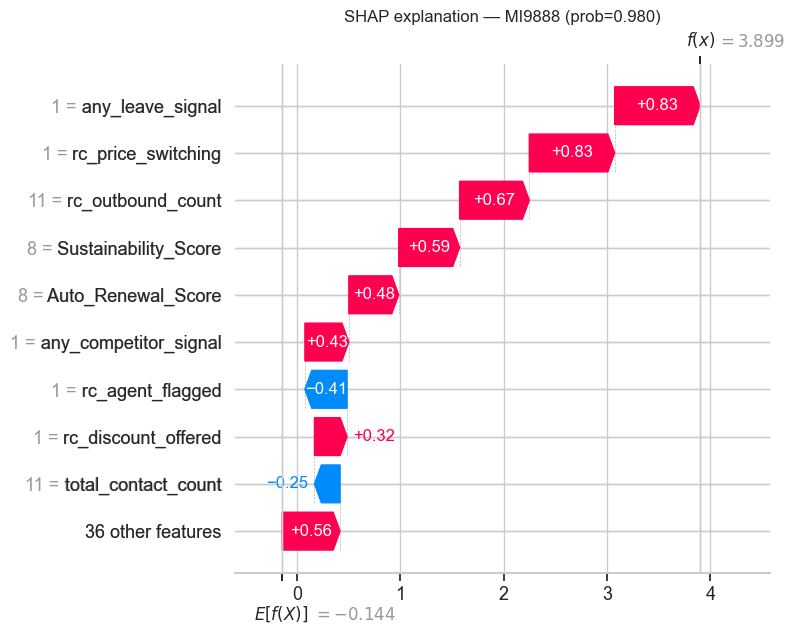


Rank 2 highest risk — Co_Ref: PD7194  Probability: 0.978
Actual label: 1


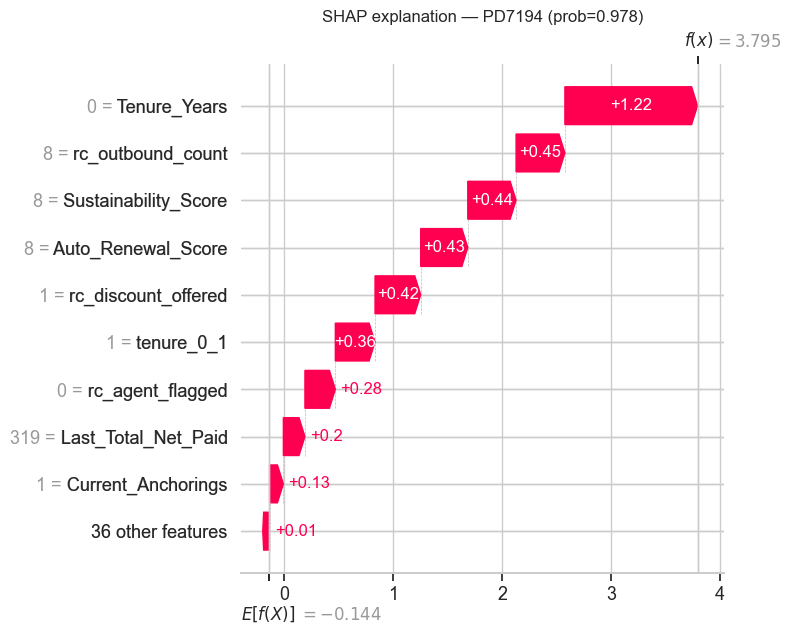


Rank 3 highest risk — Co_Ref: YD9712  Probability: 0.973
Actual label: 1


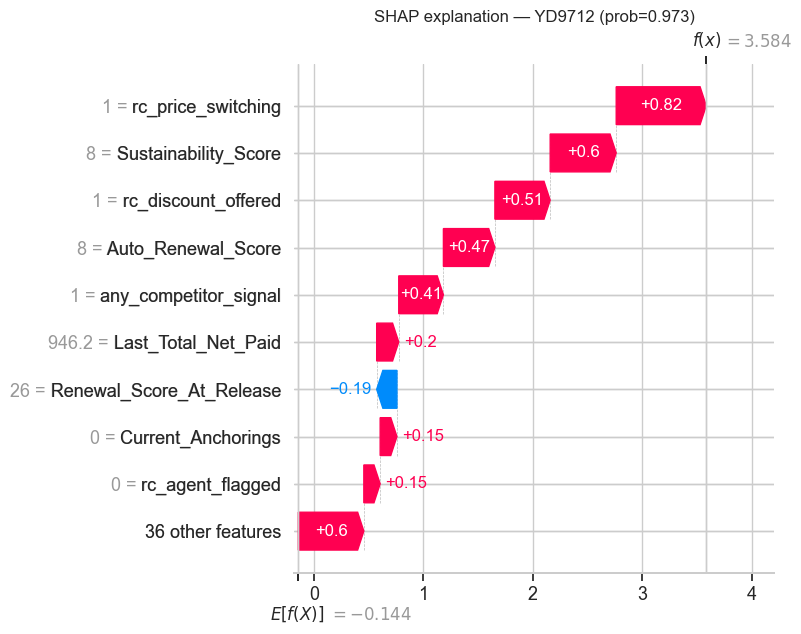

In [10]:

# Show explanations for top 3 high-risk customers from test set
proba_train = final_model.predict_proba(X_train)[:,1]
top3_idx = np.argsort(proba_train)[-3:][::-1]

for rank, idx in enumerate(top3_idx):
    co_ref = train_df.iloc[idx]['Co_Ref']
    prob   = proba_train[idx]
    print(f"\n{'='*50}")
    print(f"Rank {rank+1} highest risk — Co_Ref: {co_ref}  Probability: {prob:.3f}")
    print(f"Actual label: {y_train.iloc[idx]}")

    plt.figure(figsize=(12, 3))
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[idx],
            base_values=explainer.expected_value,
            data=X_train.iloc[idx],
            feature_names=feature_cols
        ),
        show=False, max_display=10
    )
    plt.title(f'SHAP explanation — {co_ref} (prob={prob:.3f})')
    plt.tight_layout()
    plt.savefig(REPORTS / f'shap_customer_{rank+1}.png', dpi=150, bbox_inches='tight')
    plt.show()


## Score ALL 2025 Won Customers — Final Predictions
This is the real business output. Every customer in the 2025 post-renewal cohort (4-week window) gets a churn probability score and a risk tier.


In [11]:

# Build prediction features (same pipeline, no labels)
print("Building 2025 prediction features...")
pred_df = build_cohort_features(bills, cc, rc, renewal_year=2025, include_labels=False)

# ensure same feature columns
for col in feature_cols:
    if col not in pred_df.columns:
        pred_df[col] = 0

X_pred = pred_df[feature_cols].fillna(0)

# score
pred_proba = final_model.predict_proba(X_pred)[:,1]
pred_df['churn_probability'] = pred_proba
pred_df['risk_tier'] = assign_risk_tier(pred_proba)
pred_df['churn_flag'] = (pred_proba >= optimal_threshold).astype(int)

print(f"\nScored {len(pred_df):,} customers")
print("\nRisk tier distribution:")
print(pred_df['risk_tier'].value_counts())
print(f"\nCustomers flagged for outreach: {pred_df['churn_flag'].sum():,}")


Building 2025 prediction features...
[2025] Base (4-week post-renewal window): 6,219 customers
[2025] Coverage — cc:1,903 rc:5,843
[2025] Final: (6219, 68) OK

Scored 6,219 customers

Risk tier distribution:
risk_tier
Low         2488
Medium      1865
High        1244
Critical     622
Name: count, dtype: int64

Customers flagged for outreach: 1,427


## Add Top 3 SHAP Reasons per Customer

In [12]:

print("Computing SHAP for prediction set...")
shap_pred = explainer.shap_values(X_pred)

def top_reasons(shap_row, feature_names, n=3):
    """Return top N features by absolute SHAP value."""
    idx = np.argsort(np.abs(shap_row))[-n:][::-1]
    reasons = []
    for i in idx:
        direction = 'increases' if shap_row[i] > 0 else 'decreases'
        reasons.append(f"{feature_names[i]} ({direction} risk)")
    return ' | '.join(reasons)

pred_df['top_reasons'] = [
    top_reasons(shap_pred[i], feature_cols)
    for i in range(len(pred_df))
]

print("Sample predictions for Critical Risk customers:")
critical = pred_df[pred_df['risk_tier']=='Critical'][
    ['Co_Ref','churn_probability','risk_tier','top_reasons']
].head(10)
print(critical.to_string(index=False))


Computing SHAP for prediction set...


Sample predictions for Critical Risk customers:
Co_Ref  churn_probability risk_tier                                                                                                       top_reasons
YP8535             0.7470  Critical   Sustainability_Score (increases risk) | rc_agent_flagged (decreases risk) | Auto_Renewal_Score (increases risk)
NI3159             0.9255  Critical  rc_outbound_count (increases risk) | Sustainability_Score (increases risk) | Auto_Renewal_Score (increases risk)
EN3485             0.8069  Critical rc_price_switching (increases risk) | Sustainability_Score (increases risk) | Auto_Renewal_Score (increases risk)
PN5800             0.8690  Critical  Sustainability_Score (increases risk) | rc_outbound_count (increases risk) | Auto_Renewal_Score (increases risk)
HO6750             0.8058  Critical      rc_outbound_count (increases risk) | Auto_Renewal_Score (decreases risk) | rc_agent_flagged (increases risk)
KT7721             0.7598  Critical  Sustainability_

## Save Final Predictions CSV

In [13]:

output_cols = ['Co_Ref','churn_probability','risk_tier','churn_flag','top_reasons',
               'Band','Tenure_Years','Current_Anchorings','auto_renewal_off','payment_unknown']
output_cols = [c for c in output_cols if c in pred_df.columns]

predictions = pred_df[output_cols].sort_values('churn_probability', ascending=False)
predictions['churn_probability'] = predictions['churn_probability'].round(4)

output_path = PROJECT_ROOT / 'reports' / 'churn_predictions_2025.csv'
predictions.to_csv(output_path, index=False)
print(f"Saved → {output_path}")
print(f"Total customers scored: {len(predictions):,}")
print()
print("=== FINAL SUMMARY ===")
print(f"Critical risk:  {(predictions['risk_tier']=='Critical').sum():,} customers")
print(f"High risk:      {(predictions['risk_tier']=='High').sum():,} customers")
print(f"Medium risk:    {(predictions['risk_tier']=='Medium').sum():,} customers")
print(f"Low risk:       {(predictions['risk_tier']=='Low').sum():,} customers")
print(f"\nFlagged for outreach: {predictions['churn_flag'].sum():,}")
print(f"\nModel PR-AUC: {final_metrics['pr_auc']:.4f}")
print(f"Model ROC-AUC: {final_metrics['roc_auc']:.4f}")
print(f"Precision @ threshold: {final_metrics['precision']:.4f}")
print(f"Recall    @ threshold: {final_metrics['recall']:.4f}")


Saved → c:\ds-project\post_renewal_churn_prediction\reports\churn_predictions_2025.csv
Total customers scored: 6,219

=== FINAL SUMMARY ===
Critical risk:  622 customers
High risk:      1,244 customers
Medium risk:    1,865 customers
Low risk:       2,488 customers

Flagged for outreach: 1,427

Model PR-AUC: 0.5910
Model ROC-AUC: 0.8731
Precision @ threshold: 0.5137
Recall    @ threshold: 0.6586
